# Primer intento:

El primer enfoque usa la definicion recursiva de Fibonacci con cache para evitar recalculos completos.

In [1]:
from functools import lru_cache


def primer_intento():
    @lru_cache(maxsize=None)
    def termino_fibonacci(n):
        if n < 2:
            return n
        return termino_fibonacci(n - 1) + termino_fibonacci(n - 2)

    resultado = 0
    valor = 0
    indice = 0
    while (valor := termino_fibonacci(indice)) <= 4_000_000:
        indice += 1
        if valor % 2 == 0:
            resultado += valor

    return resultado


primer_intento()

4613732

# Optimizacion:

chatgpt recomienda prescindir de la recurrencia

In [2]:
def optimizacion():
    resultado = 0
    a, b = 0, 1

    while b <= 4_000_000:
        if b % 2 == 0:
            resultado += b
        a, b = b, a + b

    return resultado


optimizacion()

4613732

# Comparacion:

Esta celda compara ambos metodos en tiempo y memoria.


--- Primer intento ---
Resultado: 4613732
Consistente: True
Repeticiones por corrida: 1000
Tiempo promedio:  11.8851 us
Tiempo mediano:   11.8298 us
Tiempo minimo:    11.5339 us
Tiempo stdev:     275.0882 ns  (CV: 2.3%)
Memoria promedio: 3.7617 KB
Memoria mediana:  3.7656 KB
Memoria maxima:   4.0859 KB
Memoria stdev:    357.1442 B
Asignaciones (mediana): 26

--- Optimizacion ---
Resultado: 4613732
Consistente: True
Repeticiones por corrida: 10000
Tiempo promedio:  1.4597 us
Tiempo mediano:   1.4595 us
Tiempo minimo:    1.4522 us
Tiempo stdev:     4.2273 ns  (CV: 0.3%)
Memoria promedio: 904.0000 B
Memoria mediana:  912.0000 B
Memoria maxima:   1008.0000 B
Memoria stdev:    95.5545 B
Asignaciones (mediana): 2

=== Comparacion directa ===
Speedup en tiempo:    8.11x  (gana: Optimizacion)
Ratio de memoria:     4.23x  (gana: Optimizacion)
Ratio asignaciones:   13.00x  (gana: Optimizacion, menos = mejor)


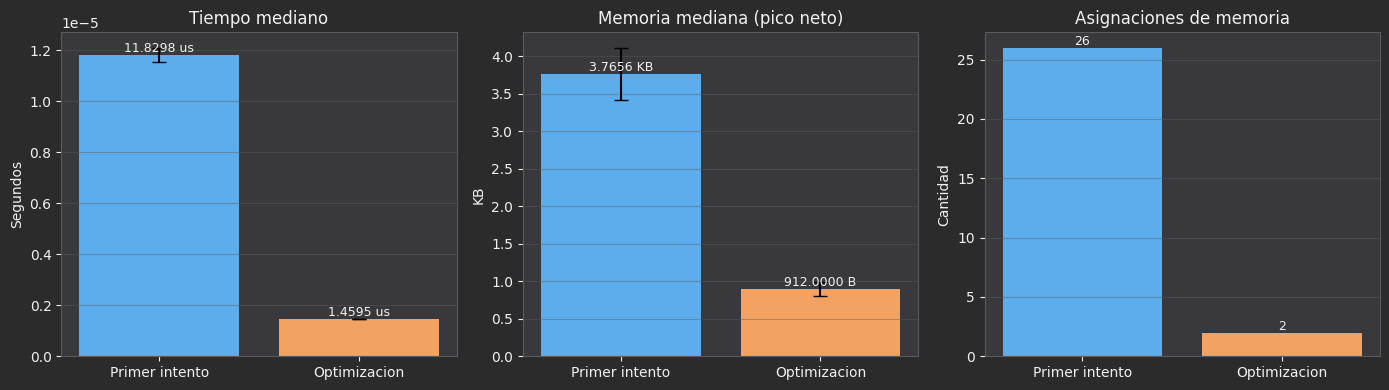

{'Primer intento': {'resultado': 4613732,
  'consistente': True,
  'tiempos': [1.173859300000002e-05,
   1.238598599999996e-05,
   1.2150429999999934e-05,
   1.1920998999999987e-05,
   1.1700700999999869e-05,
   1.192771799999992e-05,
   1.1722233999999831e-05,
   1.1533915999999866e-05],
  'memorias': [4.0390625, 4.0859375, 3.4921875, 3.4296875],
  'asignaciones': [29, 34, 22, 23],
  'repeticiones': 1000},
 'Optimizacion': {'resultado': 4613732,
  'consistente': True,
  'tiempos': [1.458155299999997e-06,
   1.458765299999998e-06,
   1.463886900000011e-06,
   1.4643705000000117e-06,
   1.4635269999999866e-06,
   1.4564387999999706e-06,
   1.4602977000000016e-06,
   1.4521602999999939e-06],
  'memorias': [0.984375, 0.921875, 0.859375, 0.765625],
  'asignaciones': [2, 2, 2, 2],
  'repeticiones': 10000}}

In [3]:
from lib.utils import comparar_metodos

comparar_metodos(primer_intento, optimizacion)